In [1]:
import json
import numpy as np
import pandas as pd
import datasets
from datasets import load_dataset
import torch
from pathlib import Path
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Bikram\anaconda3\envs\earning_call-ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("GPU name:", torch.cuda.get_device_name(0) if device == "cuda" else "N/A")

Device: cuda
GPU name: NVIDIA GeForce RTX 2050


In [ ]:
dataset = load_dataset("atrost/financial_phrasebank")

print(dataset)
print()
print("Sample:", dataset["train"][0])

C:\Users\Bikram\anaconda3\envs\earning_call-ai\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Bikram\.cache\huggingface\hub\datasets--atrost--financial_phrasebank. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 970/970 [00:00<00:00, 40507.33 examples/s]


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 3100
    })
    validation: Dataset({
        features: ['sentence', 'label'],
        num_rows: 776
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 970
    })
})

Sample: {'sentence': 'EBIT margin was up from 1.4 % to 5.1 % .', 'label': 2}


In [26]:
LABELS = ["negative", "neutral", "positive"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

X_train = list(dataset["train"]["sentence"])
y_train = list(dataset["train"]["label"])

X_val = list(dataset["validation"]["sentence"])
y_val = list(dataset["validation"]["label"])

X_test = list(dataset["test"]["sentence"])
y_test = list(dataset["test"]["label"])

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))
print("Type check:", type(X_train), type(X_train[0]))

unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(LABELS[u], ":", c)

Train: 3100 Val: 776 Test: 970
Type check: <class 'list'> <class 'str'>
negative : 382
neutral : 1852
positive : 866


In [19]:
from sklearn.utils.class_weight import compute_class_weight


In [27]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:")
print("  negative:", class_weights[0])
print("  neutral: ", class_weights[1])
print("  positive:", class_weights[2])

Class weights:
  negative: 2.7050610820244327
  neutral:  0.5579553635709144
  positive: 1.193225558121632


In [28]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts, truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [29]:
BASE_MODEL = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

train_ds = SentimentDataset(X_train, y_train, tokenizer)
val_ds = SentimentDataset(X_val, y_val, tokenizer)
test_ds = SentimentDataset(X_test, y_test, tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
    ignore_mismatched_sizes=True
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10192.66it/s]


In [32]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "accuracy": float((preds == labels).mean())
    }

training_args = TrainingArguments(
    output_dir="sentiment/checkpoints",
    num_train_epochs=10,
    per_device_train_batch_size=16 if device == "cuda" else 8,
    per_device_eval_batch_size=16 if device == "cuda" else 8,
    learning_rate=1.5e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=20,
    fp16=(device == "cuda"),
    seed=42,
    report_to="none",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [33]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [35]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.462653,0.430244,0.818613,0.853093
2,0.300188,0.329950,0.840820,0.842784
3,0.140772,0.372009,0.867245,0.882732
4,0.068896,0.475966,0.871600,0.886598
5,0.057771,0.506944,0.873307,0.889175
6,0.017234,0.573111,0.871760,0.885309
7,0.001851,0.600481,0.877247,0.891753
8,0.047621,0.582402,0.874779,0.887887
9,0.034149,0.608947,0.871465,0.887887
10,0.001002,0.602451,0.878292,0.891753


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.24it/s]


TrainOutput(global_step=1940, training_loss=0.1694430591768979, metrics={'train_runtime': 558.3017, 'train_samples_per_second': 55.526, 'train_steps_per_second': 3.475, 'total_flos': 2039128987392000.0, 'train_loss': 0.1694430591768979, 'epoch': 10.0})

In [36]:
from sklearn.metrics import confusion_matrix

In [37]:
preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)

macro_f1 = f1_score(y_test, y_pred, average="macro")
print("Test Macro F1:", macro_f1)
print()
print(classification_report(y_test, y_pred, target_names=LABELS))
print(confusion_matrix(y_test, y_pred))

Test Macro F1: 0.8477115824087642

              precision    recall  f1-score   support

    negative       0.85      0.89      0.87       125
     neutral       0.89      0.88      0.88       565
    positive       0.79      0.80      0.79       280

    accuracy                           0.85       970
   macro avg       0.84      0.85      0.85       970
weighted avg       0.86      0.85      0.85       970

[[111  12   2]
 [ 13 495  57]
 [  7  50 223]]


In [38]:
import shutil
import os

old_model_path = Path("sentiment/final")

if old_model_path.exists():
    shutil.rmtree(old_model_path)
    print("Old model removed from sentiment/final/")
else:
    print("No old model found at sentiment/final/")

Old model removed from sentiment/final/


In [39]:
final_path = "sentiment/final"

trainer.save_model(final_path)
tokenizer.save_pretrained(final_path)

metrics = {
    "macro_f1": macro_f1,
    "base_model": BASE_MODEL,
    "dataset": "atrost/financial_phrasebank",
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "note": "Switched from Twitter dataset to FinancialPhraseBank after confirming domain mismatch on real transcript-style sentences."
}

with open("sentiment/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Model saved to:", final_path)
print("Metrics saved to: sentiment/metrics.json")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.04it/s]

Model saved to: sentiment/final
Metrics saved to: sentiment/metrics.json


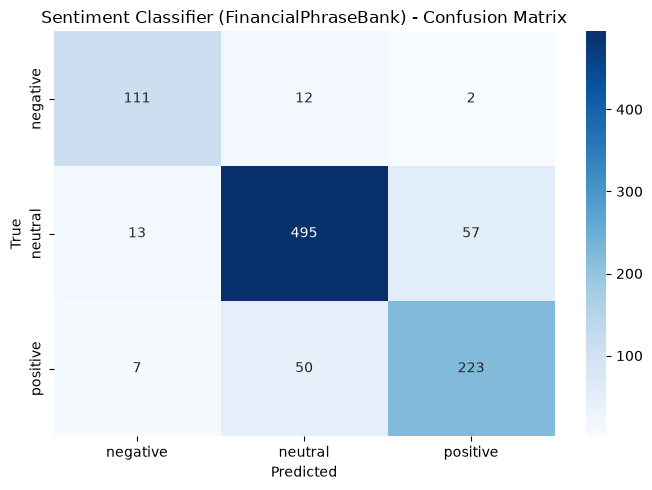

In [40]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.title("Sentiment Classifier (FinancialPhraseBank) - Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("sentiment/confusion_matrix.png", dpi=150)
plt.show()